### access dataset

In [2]:
import pandas as pd

df = pd.read_csv("../data/all_tickets_processed_improved_v3.csv")

df.head()

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47837 entries, 0 to 47836
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Document     47837 non-null  object
 1   Topic_group  47837 non-null  object
dtypes: object(2)
memory usage: 747.6+ KB


In [4]:
df.describe()

,Document,Topic_group
count,47837,47837
unique,47837,8
top,connection with icon icon dear please setup ic...,Hardware
freq,1,13617


see the distribution within the topic groups

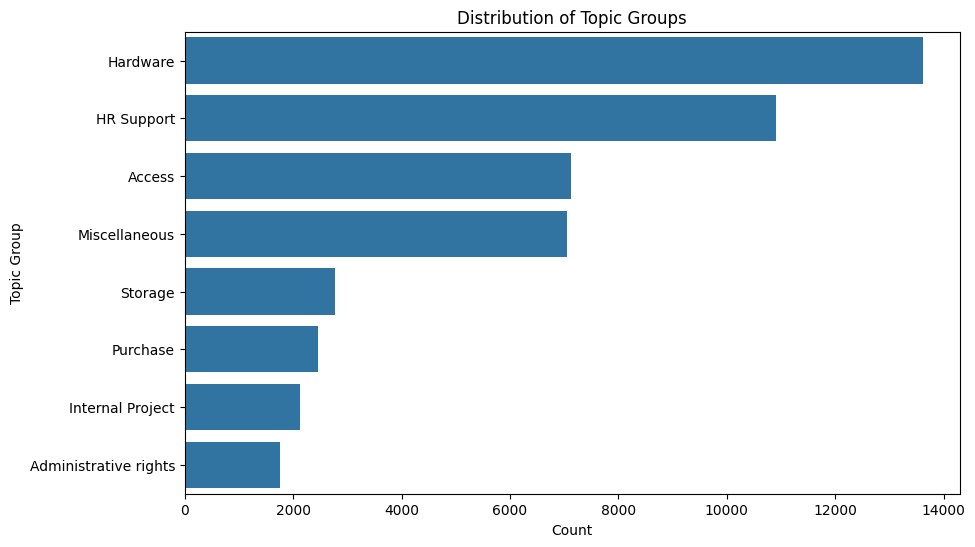

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Topic_group', order=df['Topic_group'].value_counts().index)
plt.title('Distribution of Topic Groups')
plt.xlabel('Count')
plt.ylabel('Topic Group')
plt.show()

<Axes: xlabel='Topic_group'>

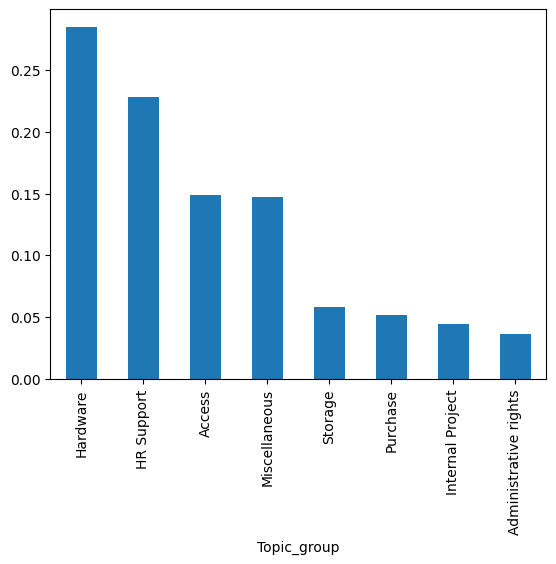

In [6]:
df['Topic_group'].value_counts(normalize=True).plot(kind='bar')

!!! The imbalance between the classes needs to be handles !!!

check on the text length


count    47837.000000
mean        43.597341
std         56.736800
min          2.000000
25%         17.000000
50%         26.000000
75%         46.000000
max        981.000000
Name: text_length, dtype: float64


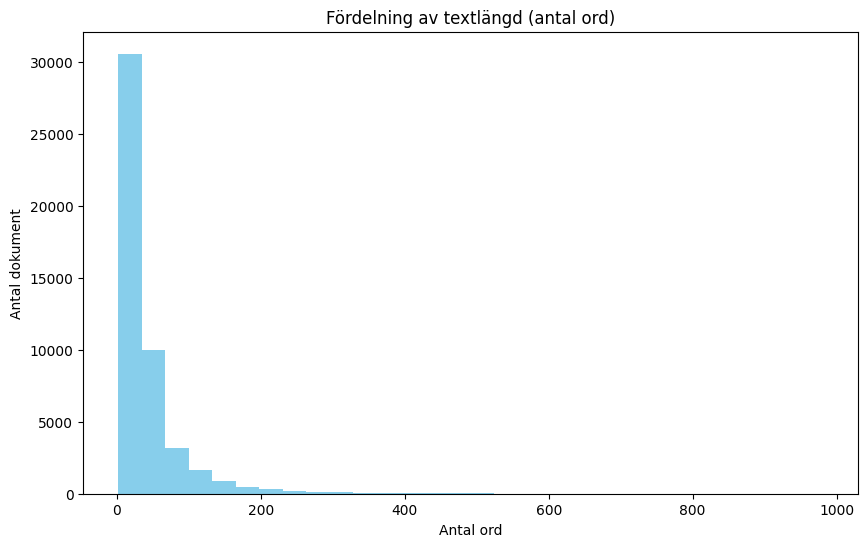

In [ ]:
df['text_length'] = df['Document'].apply(lambda x: len(x.split()))

print(df['text_length'].describe())

plt.figure(figsize=(10,6))
plt.hist(df['text_length'], bins=30, color='skyblue')
plt.title('Fördelning av textlängd (antal ord)')
plt.xlabel('Antal ord')
plt.ylabel('Antal dokument')
plt.show()

The majority of the textlength is short

text length between classes

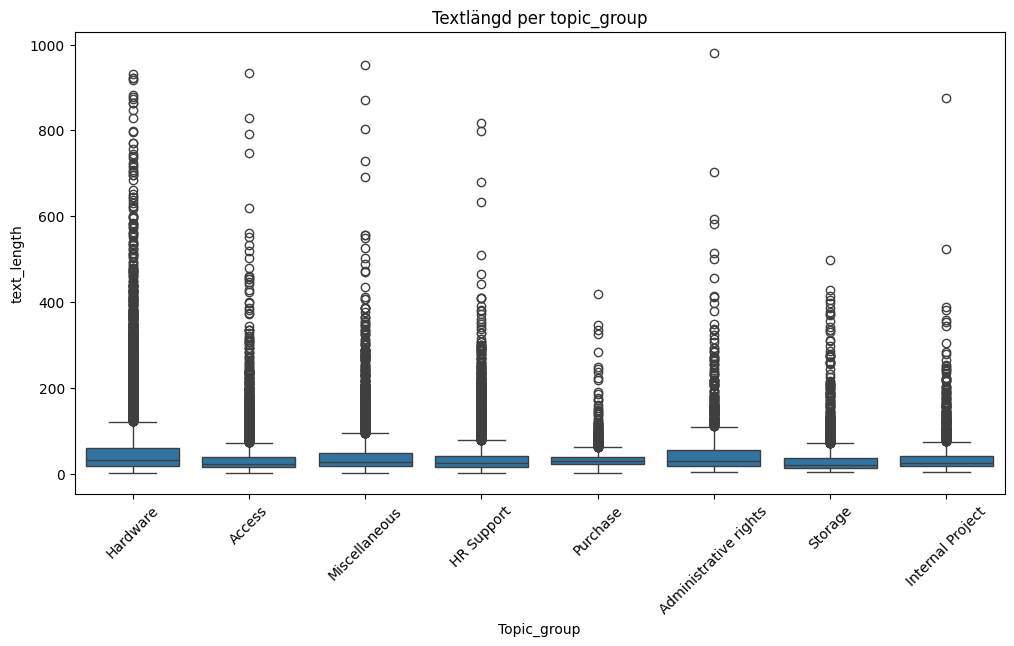

In [8]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Topic_group', y='text_length', data=df)
plt.xticks(rotation=45)
plt.title('Textlängd per topic_group')
plt.show()

The textlength is alike between the different groups but allot of outliers. Will see what these outliers are

In [9]:
long_texts = df.sort_values(by='text_length', ascending=False)

for i, row in long_texts.head(5).iterrows():
    print(f"Index: {i}")
    print(f"Length (words): {row['text_length']}")
    print(f"Topic group: {row['Topic_group']}")
    print(f"Text snippet: {row['Document'][:500]}")
    print("-" * 80)

Index: 39728
Length (words): 981
Topic group: Administrative rights
Text snippet: complete tab re complete tab please hi ll have look come back you please log ticket for assign thank you best regards administrator sent monday july fwd complete tab please hi can someone please check out access unable amend tab regards change control one canada square canary wharf change control forwarded message date july re complete tab please hi was previously able complete changes what happened be grateful if you could close one for regards notice leave monday st july friday th inclusive ma
--------------------------------------------------------------------------------
Index: 1054
Length (words): 953
Topic group: Miscellaneous
Text snippet: signed signed hello please log assign best regards senior engineer wednesday pm signed hi please example convinced problem where things updated then regress seen multiple times opportunities which close dates future which then revert close dates past more serious

!!! i preprocessing filen gör så att maximalt antal ord ligger runt 200-300 !!!

### kolla mest frekventa orden som förekommer.

please: 70212
pm: 28902
hi: 28498
regards: 27212
thank: 24962
for: 24456
hello: 23025
you: 21828
re: 21034
thanks: 19852
sent: 14717
kind: 13241
access: 13153
help: 11173
tuesday: 10896
with: 10555
wednesday: 10428
dear: 10320
thursday: 9935
can: 9526


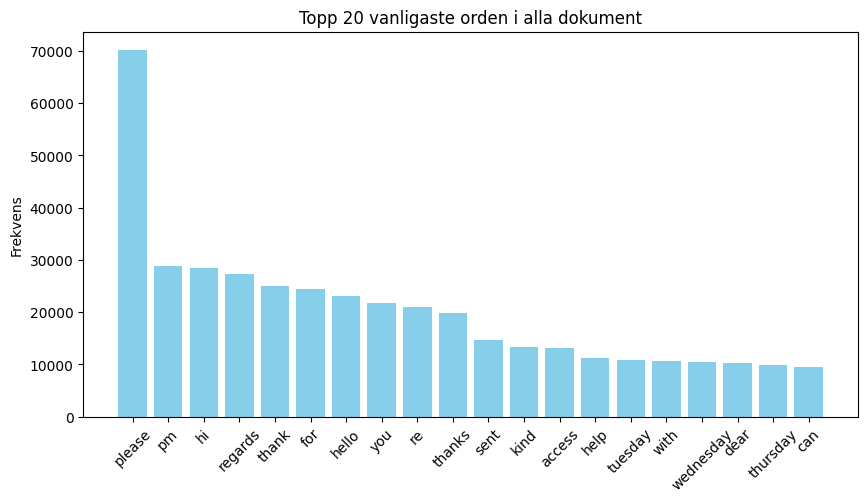

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

all_words = ' '.join(df['Document']).lower().split()

word_freq = Counter(all_words)

common_words = word_freq.most_common(20)
for word, freq in common_words:
    print(f"{word}: {freq}")

words, freqs = zip(*common_words)
plt.figure(figsize=(10,5))
plt.bar(words, freqs, color='skyblue')
plt.title("Topp 20 vanligaste orden i alla dokument")
plt.xticks(rotation=45)
plt.ylabel("Frekvens")
plt.show()

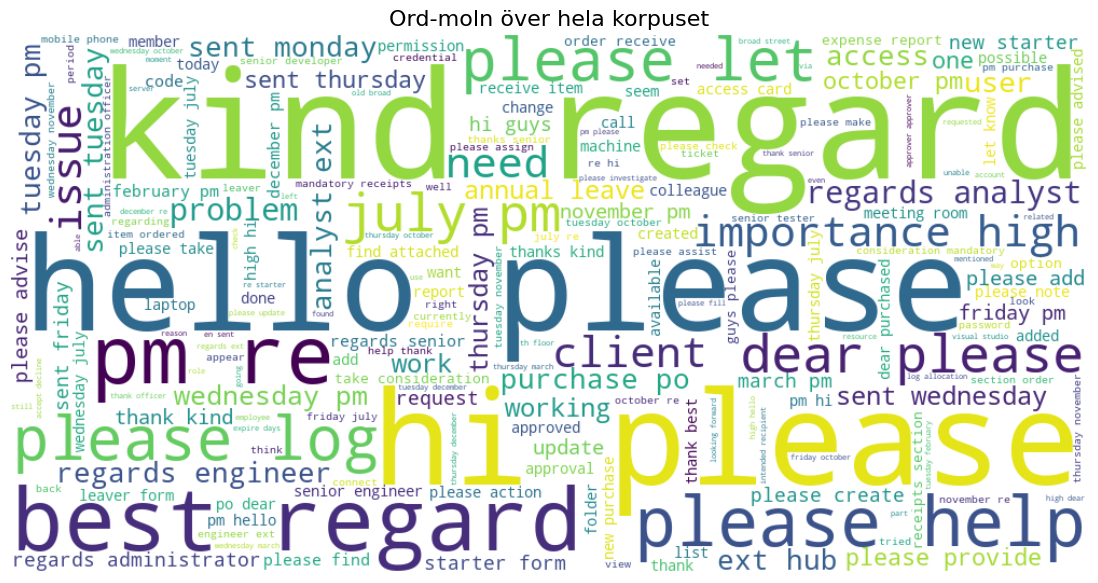

In [ ]:
from wordcloud import WordCloud

all_text = ' '.join(df['Document'])

wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(all_text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Ord-moln över hela korpuset", fontsize=16)
plt.show()

### teckentäthet och symbol analys

In [15]:
import re

df['num_uppercase'] = df['Document'].apply(lambda x: sum(1 for c in x if c.isupper()))
df['num_digits'] = df['Document'].apply(lambda x: sum(1 for c in x if c.isdigit()))
df['num_emails'] = df['Document'].apply(lambda x: len(re.findall(r'\S+@\S+', x)))
df['num_urls'] = df['Document'].apply(lambda x: len(re.findall(r'https?://\S+', x)))


df[['num_uppercase', 'num_digits', 'num_emails', 'num_urls']].mean()

num_uppercase    0.0
num_digits       0.0
num_emails       0.0
num_urls         0.0
dtype: float64

### textlängd per klass

In [14]:
length_stats = df.groupby('Topic_group')['text_length'].agg(['mean', 'std', 'min', 'max', 'count']).sort_values(by='mean', ascending=False)

print(length_stats)

                            mean        std  min  max  count
Topic_group                                                 
Hardware               56.273041  75.520222    2  931  13617
Administrative rights  50.361932  63.853702    3  981   1760
Miscellaneous          42.953966  52.186345    2  953   7060
HR Support             37.766651  42.286225    2  817  10915
Internal Project       37.706937  44.553206    4  876   2119
Access                 35.600000  47.191681    2  934   7125
Purchase               34.932630  25.866869    2  418   2464
Storage                34.409795  42.904582    5  497   2777


### Datacleaning

In [ ]:
df_duplicates = df.duplicated()
df_duplicates.value_counts()
print(f"Number of duplicate rows: {df_duplicates.sum()}")

percentage_duplicates = (df_duplicates.sum() / len(df)) * 100
print(f"Percentage of duplicate rows: {percentage_duplicates:.2f}%")

Number of duplicate rows: 0
Percentage of duplicate rows: 0.00%


In [ ]:
df_null_values = df.isnull().sum()
print(f"Number of null values in each column:\n{df_null_values}")

Number of null values in each column:
Document       0
Topic_group    0
dtype: int64
